# Spectral Embedding

Applications:

    1) draw a graph from the adjacency matrix (HW 7)
    
    2) map high-dimensional data into a low-dimensional space (R^2) #focus of today
    
    
Goal: to find a map that preserves local distances (points that are close remain close to each other are mapped to points that are also close to each other)

### Step 1:

From the data points x1,x2,...,xn in R^d, build a graph.

nodes: x1,x2,...,xn

edges: put an (unweighted) edge between nodes i and j if node j is among the k nearest neighbors of i.

weights: w_ij = 1 if there is an edge, 0 otherwise (basically an unweighted graph)

### Step 2: 
Build the Laplacian matrix L = D - A

### Step 3:
Compute the e'vals and e'vects of L.

e'vals: lambda1,lambda2,...,lambdan (in decreasing order)

e'vects: q1,q2,...,qn 

now, let Y = [qn-1,qn-2].

call the rows of Y y1,y2,...,yn

So Y^T = [y1,y2,...,yn]

map: xi to yi in R^2

the rows of Y solves 
min sum(w_ij||y_i-y_j||^2)

e^TY=0
Y^TY = I_2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

In [4]:
# load data
X=np.load('ducks.npy')

#### Data:

72 images of a rubber duck
ith image: photo taken from an angle of (i-1)*5 degrees (-,5,10,...,355)

In [5]:
X.shape

(72, 49152)

(-0.5, 127.5, 127.5, -0.5)

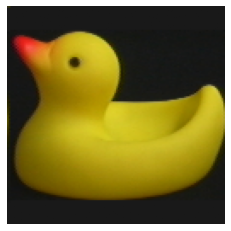

In [9]:
# each row of X is a 128*128 RGB image

image  = X[0].reshape(128,128,3)
plt.imshow(image)
plt.axis(False)

distance = 7.806347


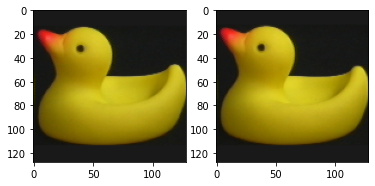

In [12]:
# grab two rows of X

i = 0
j = 1

image1 = X[i].reshape(128,128,3)
image2 = X[j].reshape(128,128,3)

plt.subplot(1,2,1)
plt.imshow(image1)
plt.subplot(1,2,2)
plt.imshow(image2)

distance = np.linalg.norm(X[i]-X[j])
print('distance = '+str(distance))

distance = 56.075634


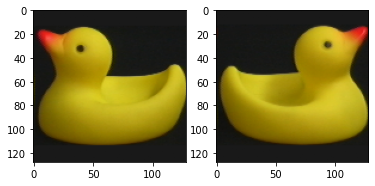

In [13]:
# grab two rows of X

i = 0
j = 35

image1 = X[i].reshape(128,128,3)
image2 = X[j].reshape(128,128,3)

plt.subplot(1,2,1)
plt.imshow(image1)
plt.subplot(1,2,2)
plt.imshow(image2)

distance = np.linalg.norm(X[i]-X[j])
print('distance = '+str(distance))

In [15]:
#distance matrix
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(X)

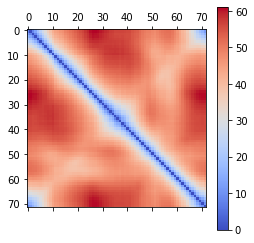

In [18]:
#visualize distance matrix

plt.matshow(distances,cmap=plt.cm.coolwarm)
plt.colorbar()

In [22]:
# nearest neighbors
n_neighbors = 5
knn = np.argsort(distances,axis=1)[:,1:n_neighbors+1]

In [23]:
# adjacency matrix
A = np.zeros(distances.shape)
for i in range(72):
    A[i,knn[i]]=1
    A[knn[i],i]=1

In [25]:
#Laplacian
L = np.diag(np.sum(A,axis =0)) - A

#evals and evects

D,V = eigh(L)


In [26]:
#two-dimensional embedding
P = V[:,[1,2]]

In [ ]:
# plot the embedding

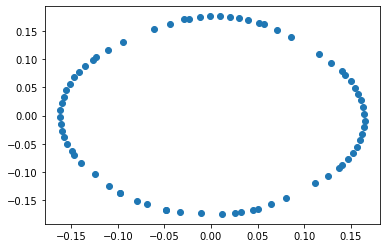

In [27]:
plt.scatter(P[:,0],P[:,1])

(-0.2, 0.2)

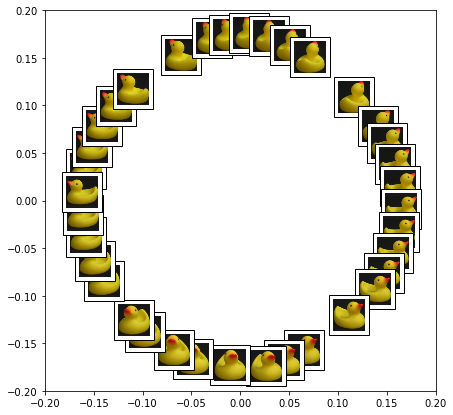

In [36]:
# advanced plot: replace blue dots with the images

fig, ax = plt.subplots(figsize=(7,7))
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
for i in range(0,72,2):
    image = X[i].reshape(128,128,3)
    image_coor = P[i]
    imagebox = AnnotationBbox(OffsetImage(image,zoom=0.25,cmap = 'binary'),image_coor)
    ax.add_artist(imagebox)
ax.set_xlim([-.2,.2])
ax.set_ylim([-.2,.2])